# Sales Analysis Project

## 1. Data Overview
## 2. Data Cleaning
## 3. Data Analysis & Visualization
## 4. Insights & Conclusions


In [ ]:
# Приєднуємо бібліотеки та підключаємо базу даних

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/mate_academy/'

events = pd.read_csv(DATA_PATH + 'events.csv')
products = pd.read_csv(DATA_PATH + 'products.csv')
countries = pd.read_csv(DATA_PATH + 'countries.csv')





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Короткий олгяд таблиці events

events.head()


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
# Короткий олгяд таблиці products

products.head()

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
# Короткий олгяд таблиці countries

countries.head()

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


Датасет підключений, всі три таблиці відображаються коректно.
Тепер проглянемо вміст таблиць та виявимо ключові поля, що їх об'єднують


In [ ]:
# Детальний зміст таблиці events

print(events.shape)
print(" ")
events.info()
print(" ")
print(events.dtypes)

(1330, 10)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
 
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object


1330 записів, 10 колонок. В колонці Country Code є 82 пропуски, Units Sold - 2; колонки Order Date та	Ship Date мають неправильний тип даних (звичайний текст замість дати). Ключові поля таблиці: **Product ID, Country Code**

In [ ]:
# Детальний зміст таблиці products

print(products.shape)
print(" ")
products.info()
print(" ")
print(products.dtypes)

(12, 2)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
 
id            int64
item_type    object
dtype: object


12 записів, 2 колонки. Пропусків немає, тип даних в таблиці - коректний, ключове поле: **id**

In [ ]:
# Детальний зміст таблиці countries

print(countries.shape)
print(" ")
countries.info()
print(" ")
print(countries.dtypes)

(249, 5)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
 
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object


249 записів, 5 колонок. Пропуски у колонках alpha-2, region, sub-region. Тип даних у таблиці вірний. ключове поле: **alpha-3**

**Висновок**: основна таблиця - events, таблиці містять незначні пропуски, також присутні помилково визначені за замовченням типи даних, ключові поля визначені.

Переходимо до **Data Cleaning**

In [ ]:
# Перевіряємо дані таблиці events

print(events.isna().sum()) #к-сть пропусків
print(" ")
misssing_persent_1 = events.isna().mean() * 100 #відсоток, але по-крутому, лише де є пропуски
misssing_persent_1 = misssing_persent_1[misssing_persent_1 > 0]
print(misssing_persent_1)
events['Country Code'] = events['Country Code'].fillna('Unknown') # заміняємо пропущенні значення в Country Code
events = events.dropna(subset=['Units Sold']) # видаляємо пропущені значення в Units Sold
events['Order Date'] = pd.to_datetime(events['Order Date']) # переводимо текст в дату
events['Ship Date'] = pd.to_datetime(events['Ship Date'])
print(" ")
for col in events.select_dtypes(include='object').columns:
    events[col] = events[col].str.strip() # видаляємо пробіли
for col in events.select_dtypes(include='object').columns:
    events[col] = events[col].str.lower() # переводимо в нижній регістр. можна було одним циклом, але я додумався пізно
print(f"duplicates: {events.duplicated().sum()}") #чекаєм дублікати
print(" ")
print(f"negative numbers:{(events[['Units Sold', 'Unit Price', 'Unit Cost']] < 0).sum()}") # шукаємо від'ємні числа
print(" ")
print(f"negative dates:{(events['Ship Date'] < events['Order Date']).sum()}") # від'ємні дати
print(" ")
events.describe() # шукаємо аномалії через опис


Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64
 
Country Code    6.165414
Units Sold      0.150376
dtype: float64
 
duplicates: 0
 
negative numbers:Units Sold    0
Unit Price    0
Unit Cost     0
dtype: int64
 
negative dates:0
 


,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


Пропуски були знайдені в двох колонках: Country Code та Units Sold, в першій колонці пропуски замінені на Unknown, оскільки були значною частиною стовпчика(6,1%), у другому - видалені, через протилежно незначний відсоток даних(~0,15%). Колонки Date успішно перетворені з тексту в дату, дублікатів знайдено не було; аномалій(від'ємних чисел, від'ємних дат, чи навпаки надзвичайно великих чисел) під час перевірки знайдено не було.

In [ ]:
# Перевіряємо дані таблиці products

for col in products.select_dtypes(include='object').columns:
    products[col] = products[col].str.strip() # видаляємо пробіли
for col in products.select_dtypes(include='object').columns:
    products[col] = products[col].str.lower() # переводимо в нижній регістр. можна було одним циклом, але я додумався пізно
print(f"duplicates: {products.duplicated().sum()}") #чекаєм дублікати
print(" ")
products.describe() # шукаємо аномалії через опис




duplicates: 0
 


,id
count,12.000000
mean,5802.166667
std,2937.985452
min,1270.000000
25%,2959.000000
50%,6659.500000
75%,8390.000000
max,8969.000000


Пропусків у таблиці попередньо виявлено не було, тому операцій по роботі з ними також проведено не було, дублікатів і аномалій не знайдено.

In [ ]:
# Перевіряємо дані таблиці countries

print(countries.isna().sum()) #к-сть пропусків
print(" ")
misssing_persent_2 = countries.isna().mean() * 100 #відсоток, але по-крутому, лише де є пропуски
misssing_persent_2 = misssing_persent_2[misssing_persent_2 > 0]
print(misssing_persent_2)
countries = countries.fillna('Unknown') #заміняємо пропуски на 'Unknown'
print(" ")
for col in countries.select_dtypes(include='object').columns:
    countries[col] = countries[col].str.strip() # видаляємо пробіли
for col in countries.select_dtypes(include='object').columns:
    countries[col] = countries[col].str.lower() # переводимо в нижній регістр. можна було одним циклом, але я додумався пізно
print(f"duplicates: {countries.duplicated().sum()}") #чекаєм дублікати
print(" ")
countries.describe() # шукаємо аномалії через опис


name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64
 
alpha-2       0.401606
region        0.401606
sub-region    0.401606
dtype: float64
 
duplicates: 0
 


,name,alpha-2,alpha-3,region,sub-region
count,249,249,249,249,249
unique,249,249,249,6,18
top,afghanistan,af,afg,africa,sub-saharan africa
freq,1,1,1,60,53


Пропуски в таблиці countries були замінені на Unknown, оскільки це dimension таблиця і нам важливо зберети дані країн, дублів та аномалій немає

In [ ]:

df = pd.merge(events, products, left_on="Product ID", right_on="id", how="left")# джойнимо таблиці
df = pd.merge(df, countries, left_on="Country Code", right_on="alpha-3", how="left")
trash = ['id','alpha-2', 'alpha-3', 'Order Priority', 'Country Code', 'Product ID']# видаляємо однакові та технічні стовпці
df = df.drop(trash, axis=1)
df = df.rename(columns={
    "name": "Country",
    "item_type": "Category",
    "region": "Region",
    "sub-region": "SubRegion"
}) #даємо колонкам нормальну назву
df['Revenue'] = df['Units Sold'] * df['Unit Price'] #нові колонки створюємо
df['Profit'] = df['Units Sold'] - df['Unit Cost']
df['Cost'] = df['Units Sold'] * df['Unit Cost']
df['Shipping Time'] = df['Ship Date'] - df['Order Date']
df["DayOfWeek"] = df["Order Date"].dt.day_name() #створюю колонку днів тижня, та формую список щоб матплотліб не по алфавіту візуалізацію робив
days_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"]
df["DayOfWeek"] = pd.Categorical(
    df["DayOfWeek"],
    categories=days_order,
    ordered=True)
df["YearMonth"] = df["Order Date"].dt.to_period("M").dt.to_timestamp()
df["Shipping Time"] = df["Shipping Time"].dt.days # переводимо в дні
total_orders = df['Order ID'].nunique() #загальна кількість замовлень
print(f"total_orders: {total_orders}")
print(" ")
total_profit = df['Profit'].sum() #total profit
print(f"total_profit: {total_profit}")
print(" ")
total_country = df['Country'].nunique() #к-сть країн
print(f"total_country: {total_country}")
print(" ")
total_revenue = df['Revenue'].sum() #total Revenue
print(f"total_revenue: {total_revenue}")
print(" ")
avg_order_value = df['Revenue'].mean() #середній чек
print(f"avg_order_value:{avg_order_value}")
df.head()

total_orders: 1328
 
total_profit: 6327907.1
 
total_country: 45
 
total_revenue: 1702129408.21
 
avg_order_value:1281723.9519653614


,Order ID,Order Date,Ship Date,Sales Channel,Units Sold,Unit Price,Unit Cost,Category,Country,Region,SubRegion,Revenue,Profit,Cost,Shipping Time,DayOfWeek,YearMonth
0,100640618,2014-10-08,2014-10-18,online,650.0,205.70,117.11,cereal,norway,europe,northern europe,133705.00,532.89,76121.50,10,Wednesday,2014-10-01
1,100983083,2016-08-11,2016-08-11,offline,1993.0,205.70,117.11,cereal,serbia,europe,southern europe,409960.10,1875.89,233400.23,0,Thursday,2016-08-01
2,101025998,2014-07-18,2014-08-11,online,4693.0,668.27,502.54,household,NaN,NaN,NaN,3136191.11,4190.46,2358420.22,24,Friday,2014-07-01
3,102230632,2017-05-13,2017-06-13,online,1171.0,109.28,35.84,clothes,montenegro,europe,southern europe,127966.88,1135.16,41968.64,31,Saturday,2017-05-01
4,103435266,2012-08-11,2012-09-18,offline,7648.0,47.45,31.79,beverages,serbia,europe,southern europe,362897.60,7616.21,243129.92,38,Saturday,2012-08-01


Всі таблиці успішно об'єданні в одну. Було видалено колонки технічного характеру та колонки-дублікати; надано більш відповідні назви певним колонкам. Було створено нові колонки для подальших розрахунків: Revenue, Profit,	Shipping Time та ключові метрики: total_orders, total_profit, total_country,   total_revenue

/tmp/ipython-input-3816348145.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rv_grouped_by_category, x="Category", y="Revenue", palette="tab10", )


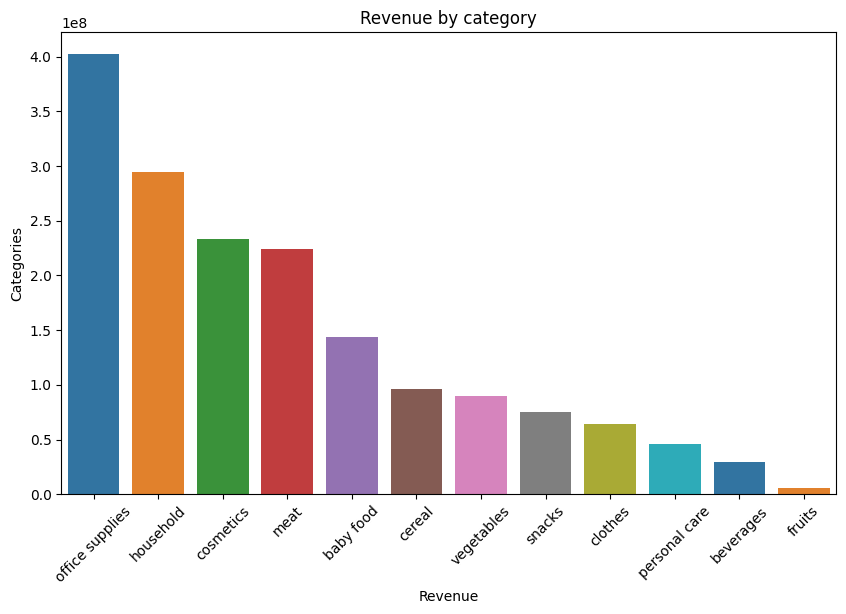

In [ ]:
rv_grouped_by_category = df.groupby(["Category"])[["Revenue", "Profit", "Cost", "Units Sold"]].sum().reset_index() # групуємо дохід та прибуток по категоріям
rv_grouped_by_category = rv_grouped_by_category.sort_values("Revenue", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=rv_grouped_by_category, x="Category", y="Revenue", palette="tab10", )
plt.xticks(rotation=45)
plt.title("Revenue by category")  # Title of the graph
plt.xlabel("Revenue")  # X-axis label
plt.ylabel("Categories")  # Y-axis label
plt.show()


Як ми бачимо у розрізі категорій найбільший дохід приносить офісне приладдя, побутові приладдя та косметика

/tmp/ipython-input-1683883947.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rv_grouped_by_category, x="Category", y="Profit", palette="tab10")


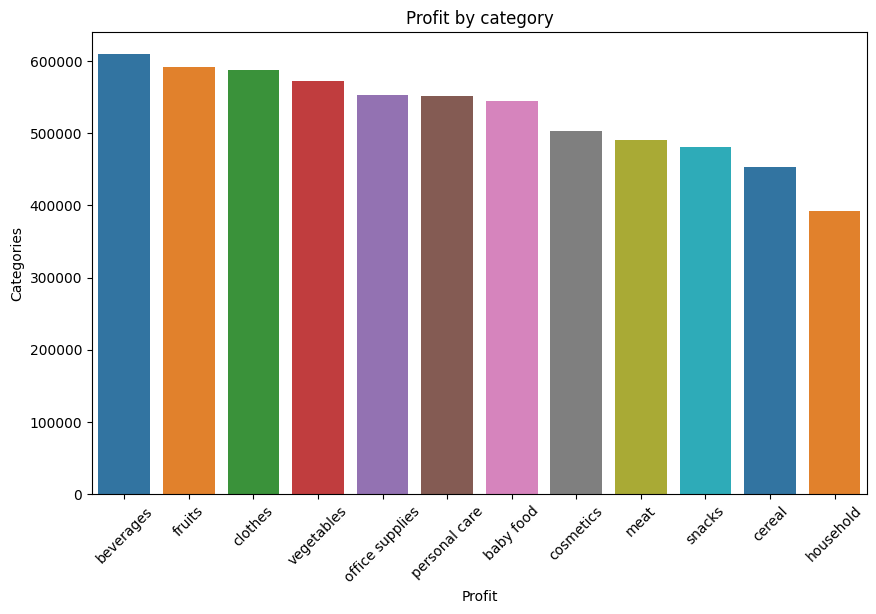

In [ ]:
rv_grouped_by_category = rv_grouped_by_category.sort_values("Profit", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=rv_grouped_by_category, x="Category", y="Profit", palette="tab10")
plt.xticks(rotation=45)
plt.title("Profit by category")  # Title of the graph
plt.xlabel("Profit")  # X-axis label
plt.ylabel("Categories")  # Y-axis label
plt.show()

По прибутку лідирують напоЇ, фрукти та одяг

/tmp/ipython-input-551789089.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rv_grouped_by_category, x="Category", y="Cost", palette="tab10")


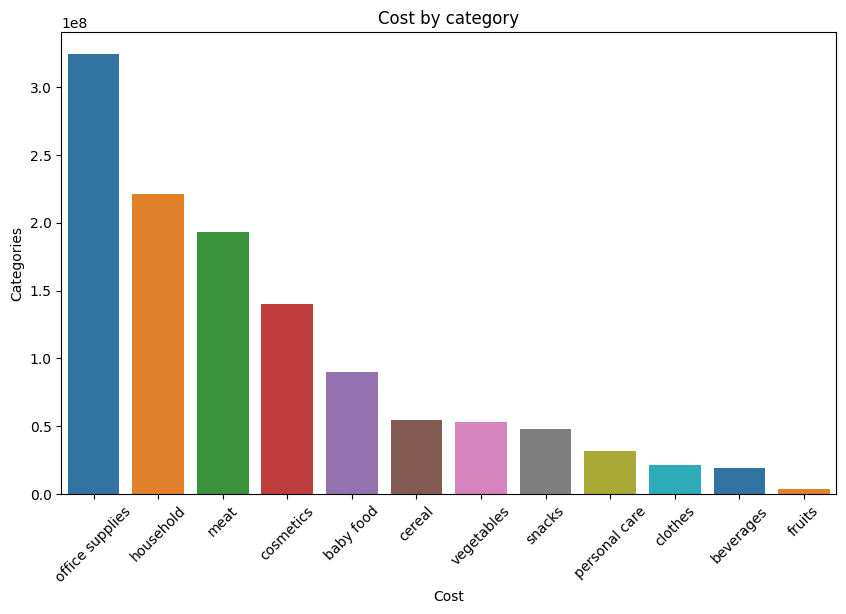

In [ ]:
rv_grouped_by_category = rv_grouped_by_category.sort_values("Cost", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=rv_grouped_by_category, x="Category", y="Cost", palette="tab10")
plt.xticks(rotation=45)
plt.title("Cost by category")  # Title of the graph
plt.xlabel("Cost")  # X-axis label
plt.ylabel("Categories")  # Y-axis label
plt.show()

По витратам перші місця займає офісне приладдя, побутове приладдя та м'ясо

/tmp/ipython-input-2331477021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rv_grouped_by_category, x="Category", y="Units Sold", palette="tab10")


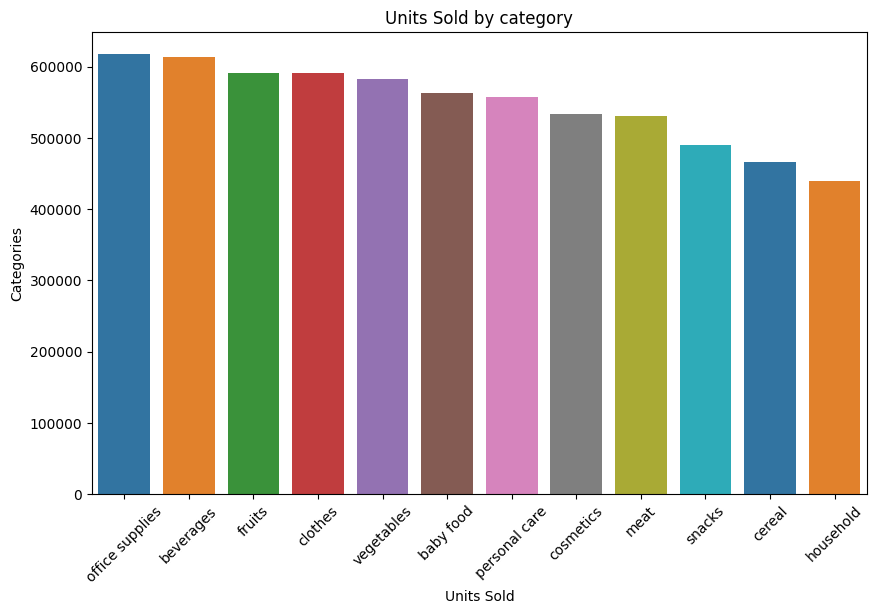

In [ ]:
rv_grouped_by_category = rv_grouped_by_category.sort_values("Units Sold", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=rv_grouped_by_category, x="Category", y="Units Sold", palette="tab10")
plt.xticks(rotation=45)
plt.title("Units Sold by category")  # Title of the graph
plt.xlabel("Units Sold")  # X-axis label
plt.ylabel("Categories")  # Y-axis label
plt.show()

Найчастіше клієнти купляють офісне приладдя, напої та фрукти

/tmp/ipython-input-3188294462.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rv_grouped_by_country, x="Country", y="Revenue", palette="tab10", )


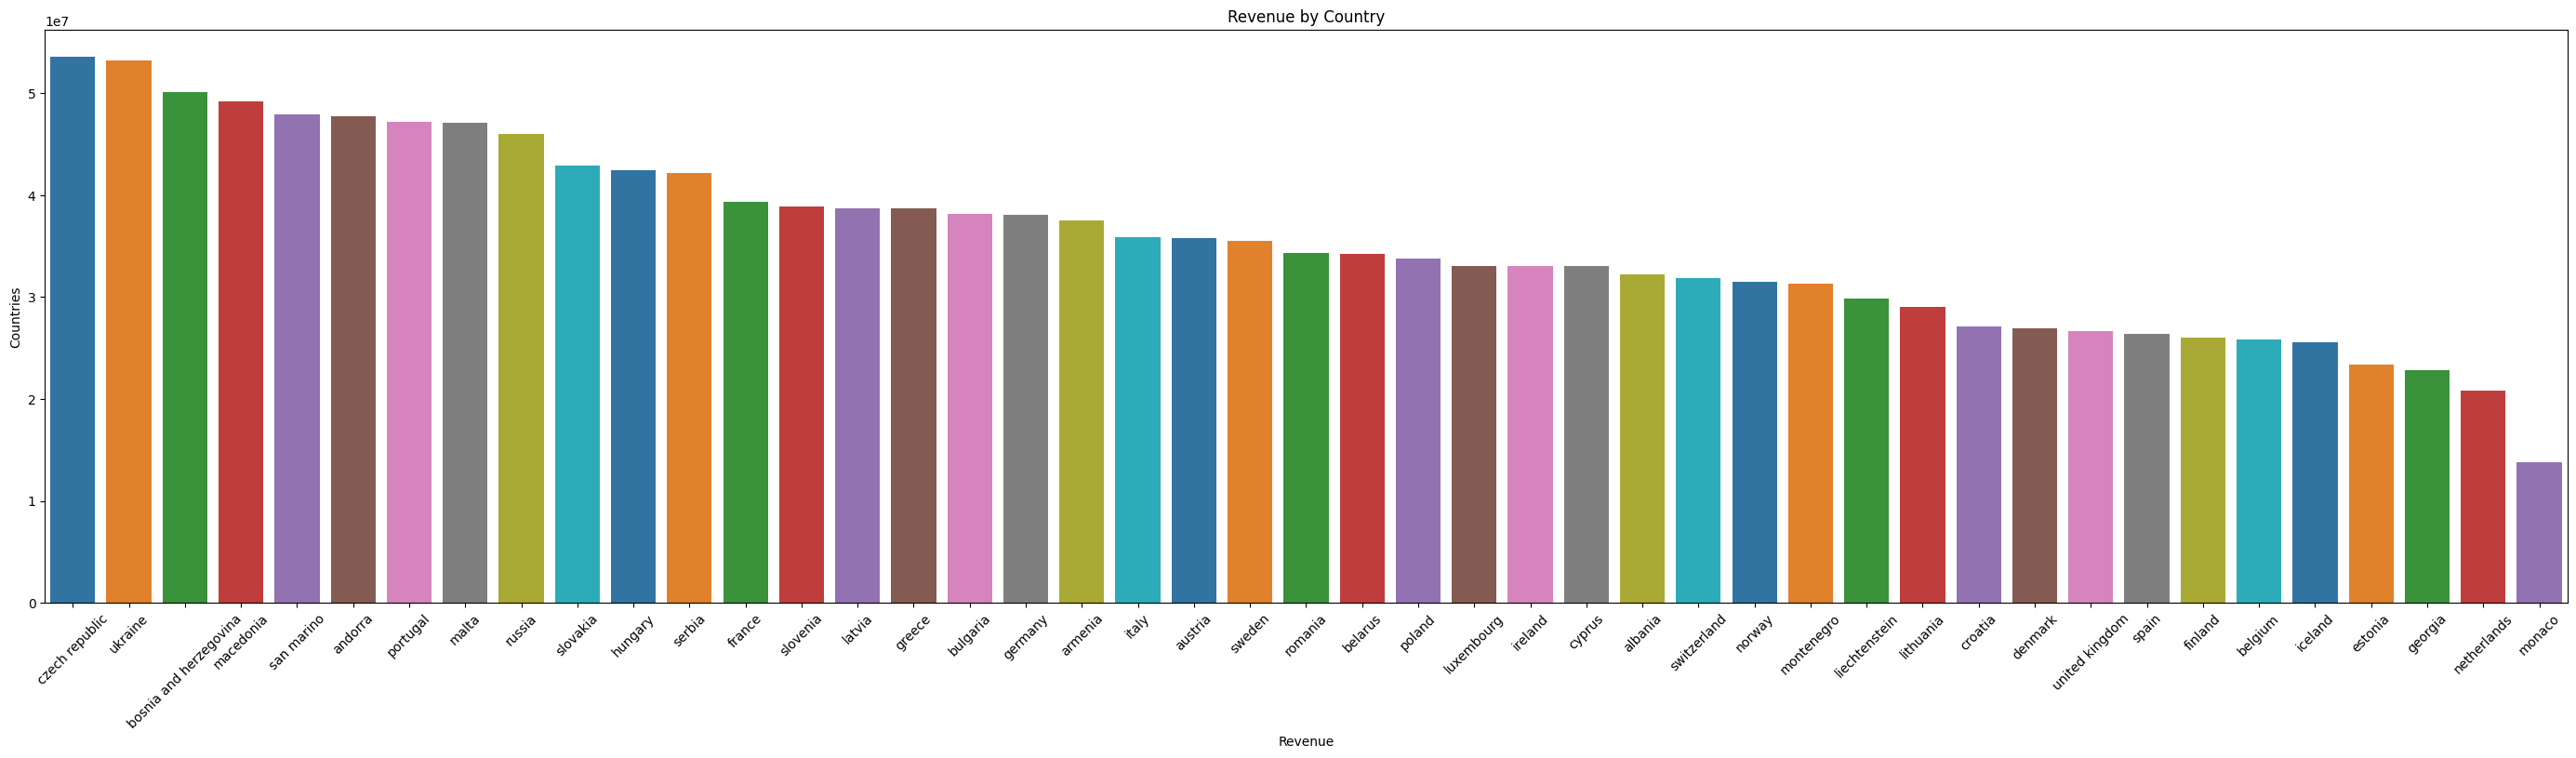

In [ ]:
rv_grouped_by_country = df.groupby(["Country"])[["Revenue", "Profit", "Cost", "Units Sold"]].sum().reset_index() # групуємо дохід та прибуток по країнам
rv_grouped_by_country = rv_grouped_by_country.sort_values("Revenue", ascending=False)
plt.figure(figsize=(35,8))
sns.barplot(data=rv_grouped_by_country, x="Country", y="Revenue", palette="tab10", )
plt.xticks(rotation=45)
plt.title("Revenue by Country")  # Title of the graph
plt.xlabel("Revenue")  # X-axis label
plt.ylabel("Countries")  # Y-axis label
plt.show()



По доходу серед країн домінує Чехія, Україна і Боснія та Герцоговина

/tmp/ipython-input-1297415700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rv_grouped_by_country, x="Country", y="Profit", palette="tab10", )


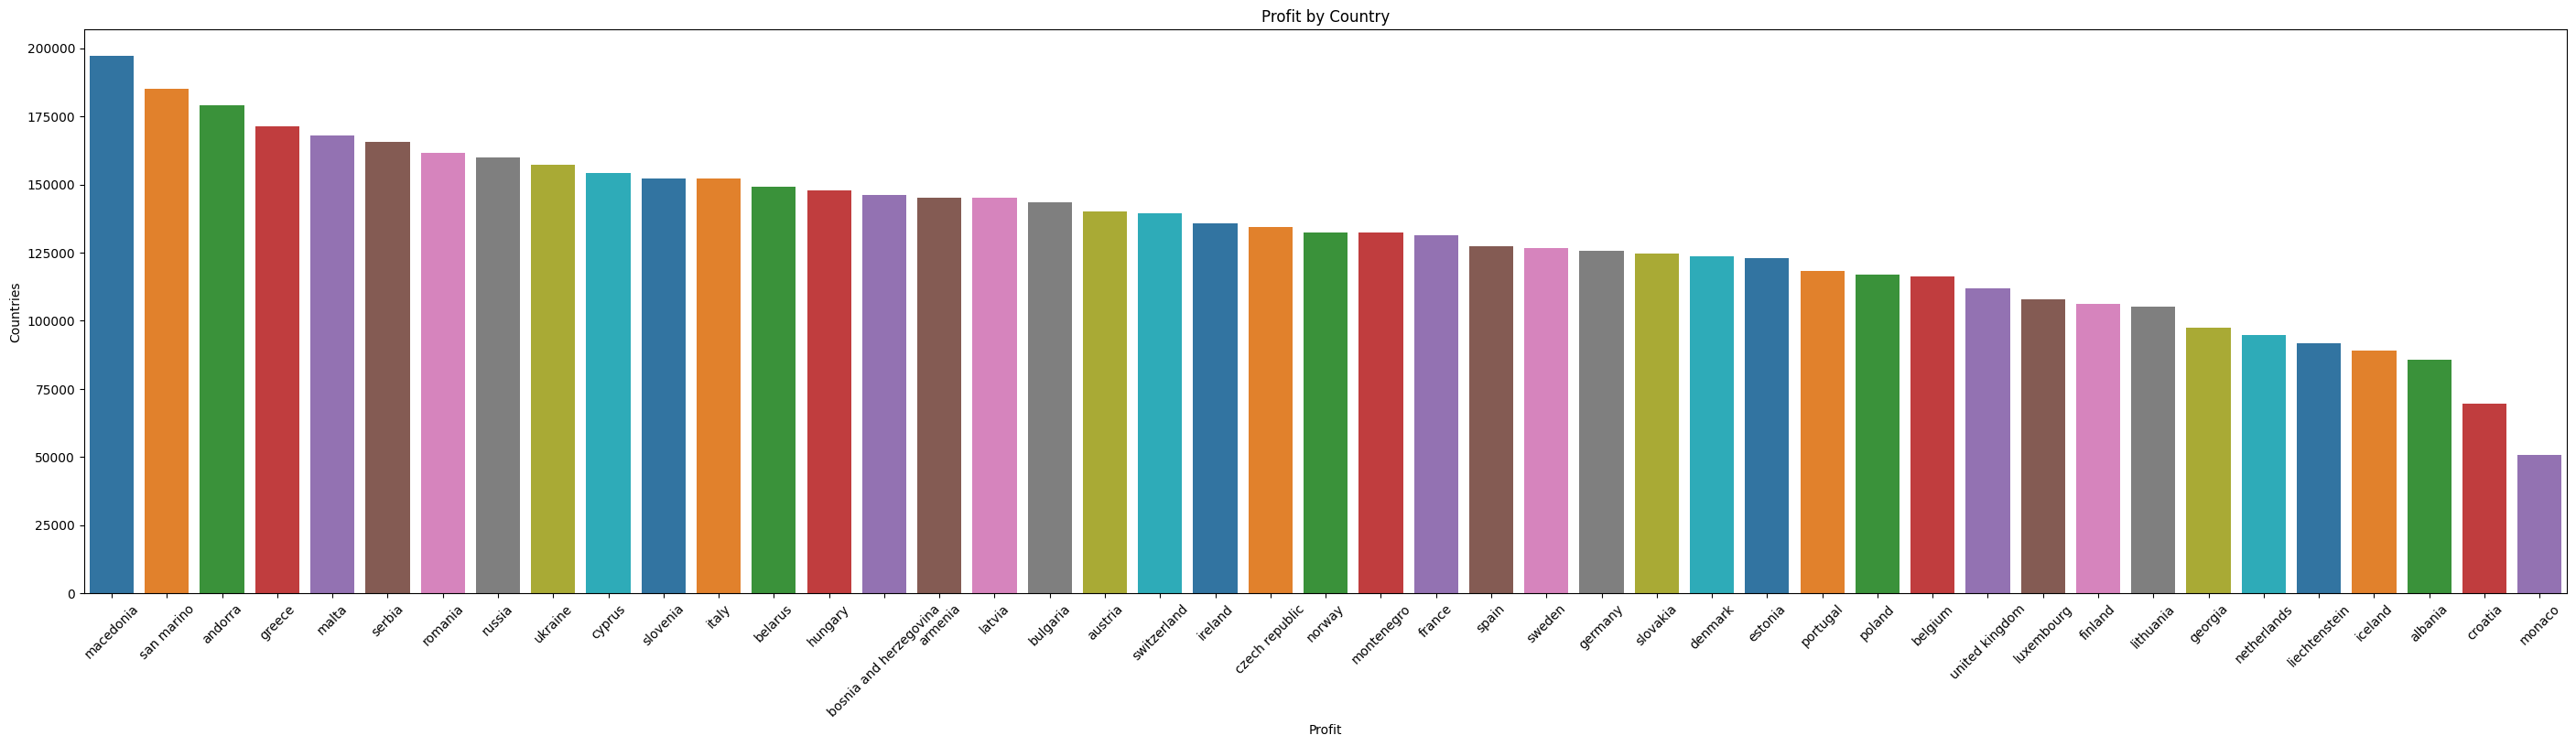

In [ ]:
rv_grouped_by_country = rv_grouped_by_country.sort_values("Profit", ascending=False)
plt.figure(figsize=(35,8))
sns.barplot(data=rv_grouped_by_country, x="Country", y="Profit", palette="tab10", )
plt.xticks(rotation=45)
plt.title("Profit by Country")  # Title of the graph
plt.xlabel("Profit")  # X-axis label
plt.ylabel("Countries")  # Y-axis label
plt.show()

По прибутку - Македонія, Сан Маріно та Андорра

/tmp/ipython-input-3865660911.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rv_grouped_by_country, x="Country", y="Cost", palette="tab10", )


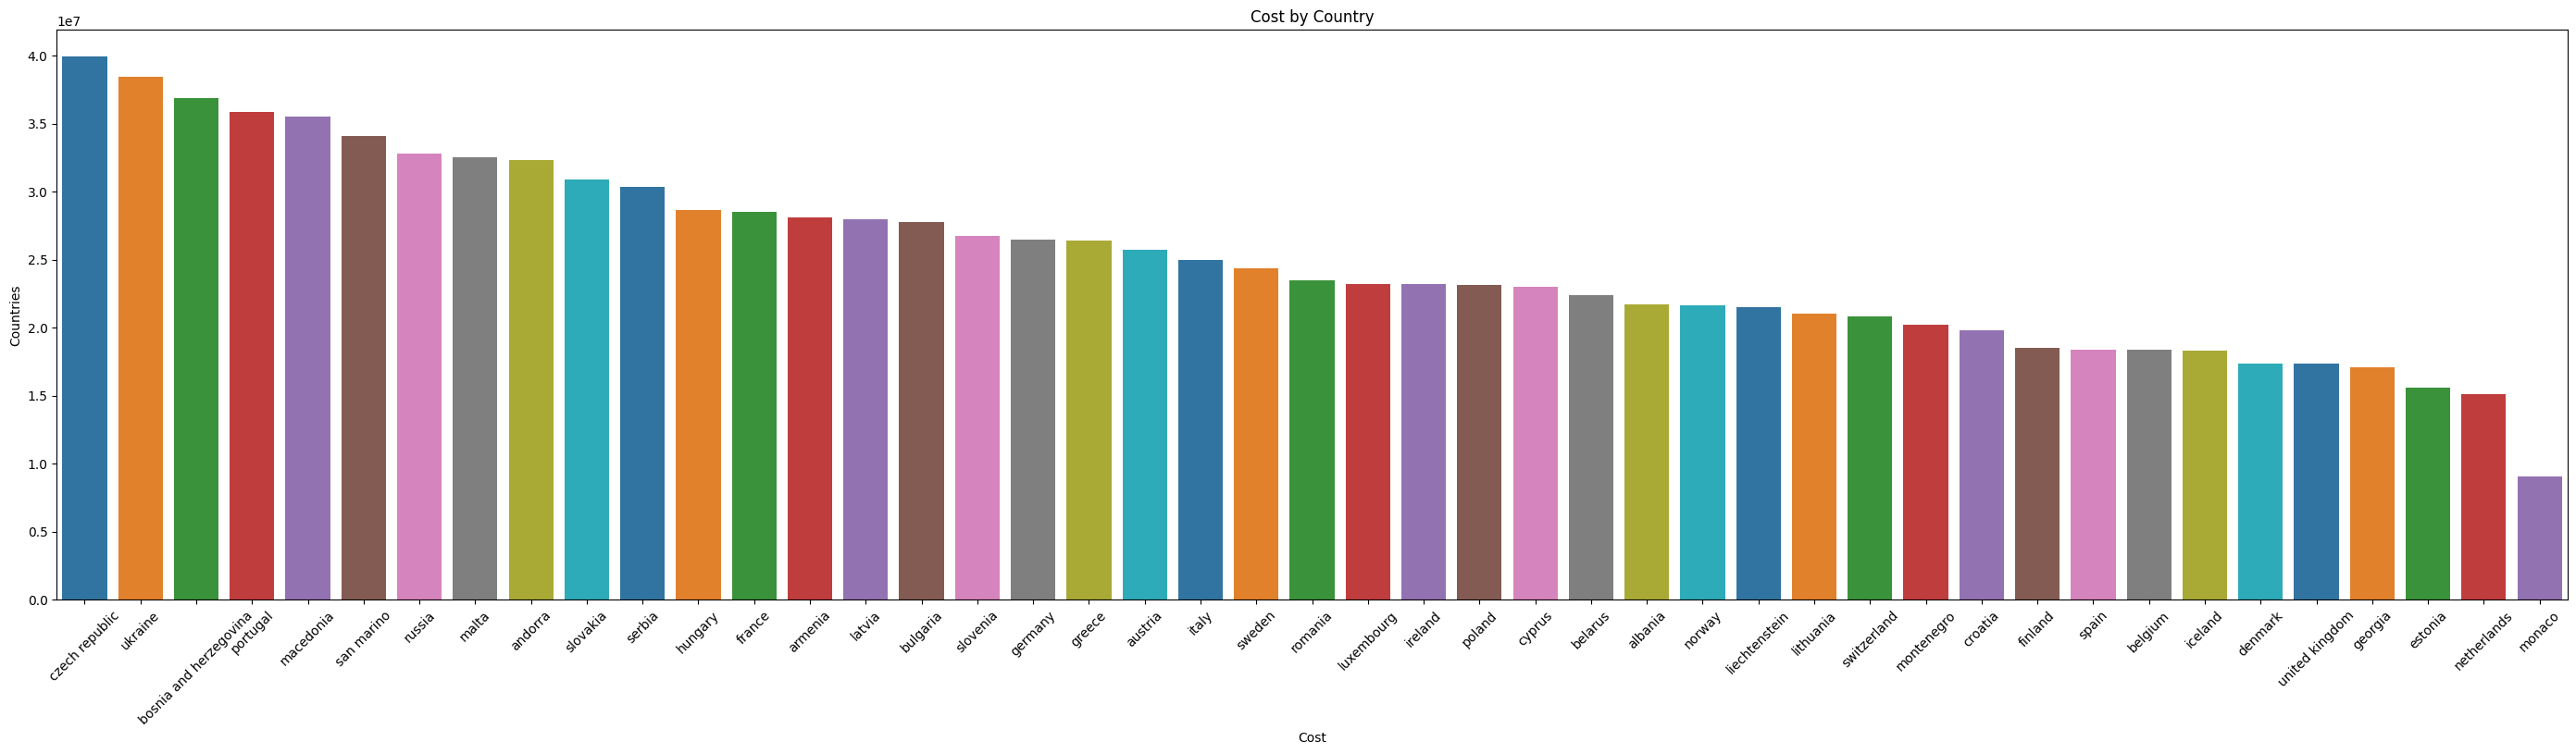

In [ ]:
rv_grouped_by_country = rv_grouped_by_country.sort_values("Cost", ascending=False)
plt.figure(figsize=(35,8))
sns.barplot(data=rv_grouped_by_country, x="Country", y="Cost", palette="tab10", )
plt.xticks(rotation=45)
plt.title("Cost by Country")  # Title of the graph
plt.xlabel("Cost")  # X-axis label
plt.ylabel("Countries")  # Y-axis label
plt.show()

Витрати - аналогічно з доходом

/tmp/ipython-input-1348803416.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rv_grouped_by_country, x="Country", y="Units Sold", palette="tab10", )


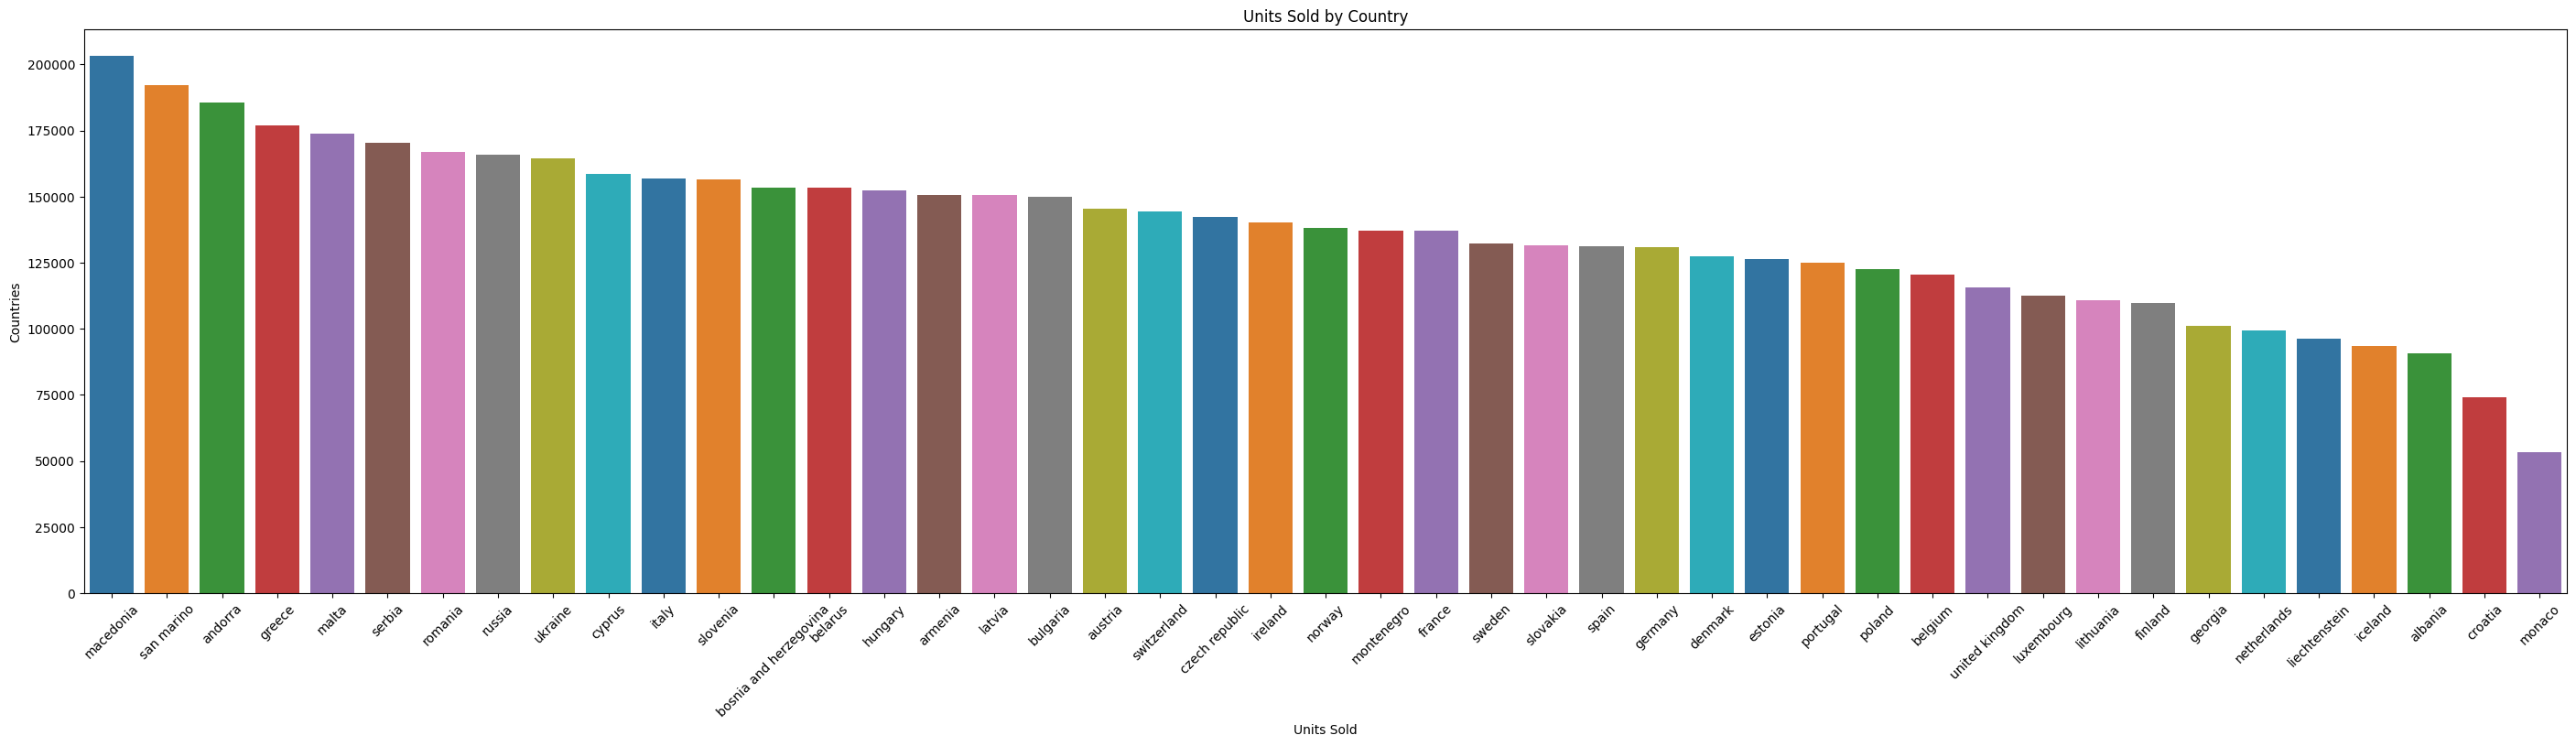

In [ ]:
rv_grouped_by_country = rv_grouped_by_country.sort_values("Units Sold", ascending=False)
plt.figure(figsize=(35,8))
sns.barplot(data=rv_grouped_by_country, x="Country", y="Units Sold", palette="tab10", )
plt.xticks(rotation=45)
plt.title("Units Sold by Country")  # Title of the graph
plt.xlabel("Units Sold")  # X-axis label
plt.ylabel("Countries")  # Y-axis label
plt.show()

К-сть продажів аналогічна результатам прибутку

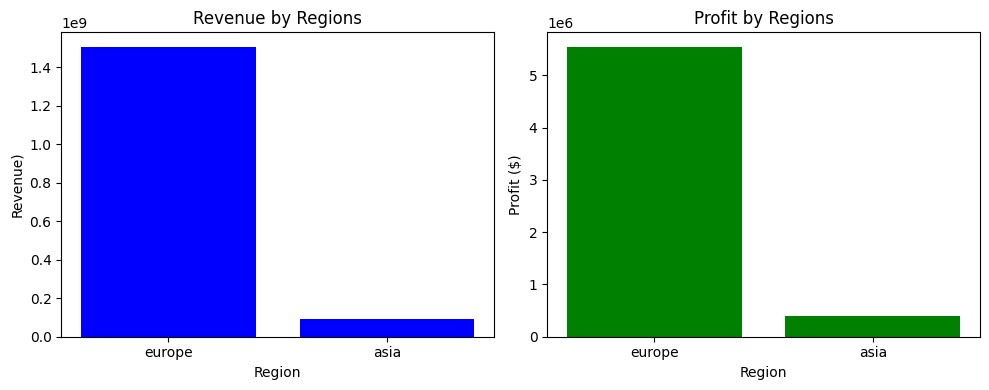

In [ ]:
rv_grouped_by_region = df.groupby(["Region"])[["Revenue", "Profit", "Cost", "Units Sold"]].sum().reset_index() # групуємо дохід та прибуток по регіоном
rv_grouped_by_region = rv_grouped_by_region.sort_values("Revenue", ascending=False)
# Create a figure with 1 row and 2 columns of subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# First subplot - Bar plot
ax[0].bar(rv_grouped_by_region["Region"], rv_grouped_by_region["Revenue"], color="blue")
ax[0].set_title("Revenue by Regions")  # Title of the subplot
ax[0].set_xlabel("Region")  # X-axis label
ax[0].set_ylabel("Revenue)")  # Y-axis label

# Second subplot - Bar plot
ax[1].bar(rv_grouped_by_region["Region"], rv_grouped_by_region["Profit"], color="green")
ax[1].set_title("Profit by Regions")  # Title of the subplot
ax[1].set_xlabel("Region")  # X-axis label
ax[1].set_ylabel("Profit ($)")  # Y-axis label

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

Європа значно перевищує Азію за дохідністю та прибутком

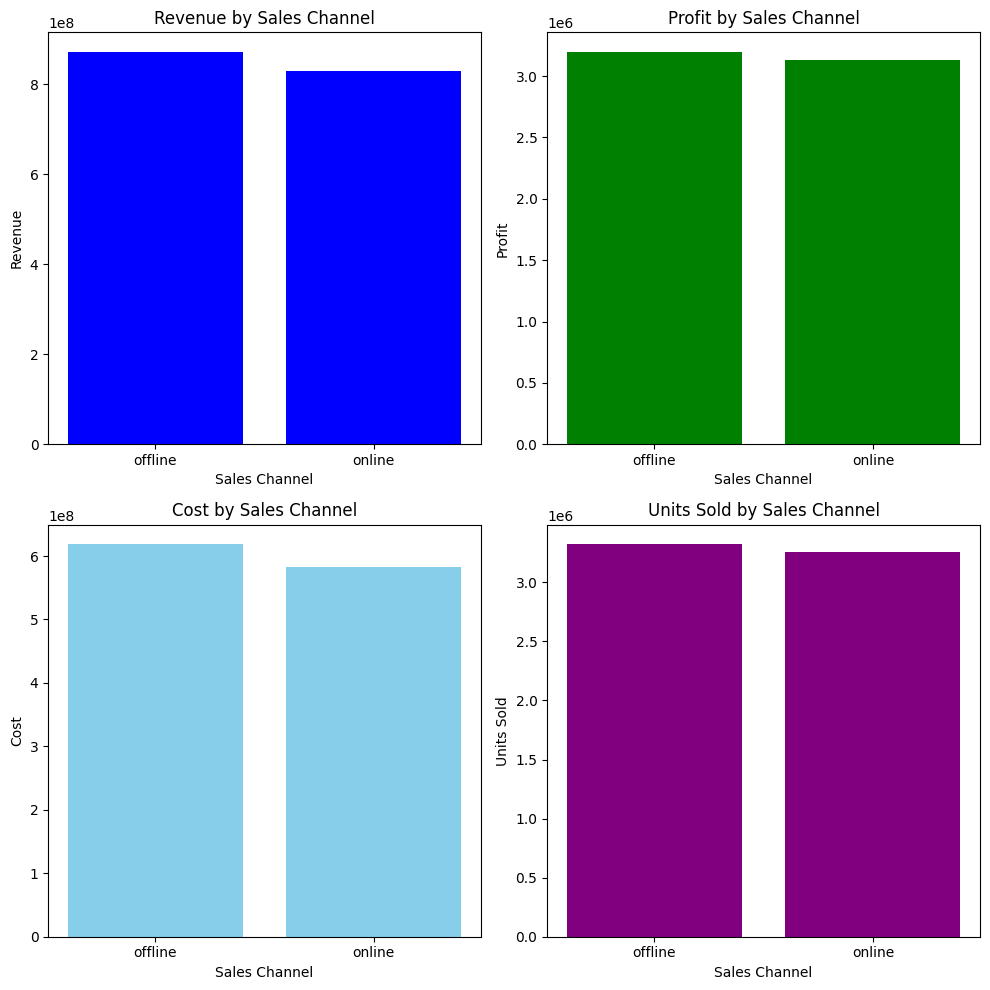

In [ ]:
rv_grouped_by_channel = df.groupby(["Sales Channel"])[["Revenue", "Profit", "Cost", "Units Sold"]].sum().reset_index() # групуємо дохід та прибуток по регіоном
rv_grouped_by_channel = rv_grouped_by_channel.sort_values("Revenue", ascending=False)
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

ax[0, 0].bar(rv_grouped_by_channel["Sales Channel"], rv_grouped_by_channel["Revenue"], color="blue")
ax[0, 0].set_title("Revenue by Sales Channel")  # Title of the subplot
ax[0, 0].set_xlabel("Sales Channel")  # X-axis label
ax[0, 0].set_ylabel("Revenue")  # Y-axis label

ax[0, 1].bar(rv_grouped_by_channel["Sales Channel"], rv_grouped_by_channel["Profit"], color="green")
ax[0, 1].set_title("Profit by Sales Channel")  # Title of the subplot
ax[0, 1].set_xlabel("Sales Channel")  # X-axis label
ax[0, 1].set_ylabel("Profit")  # Y-axis label

ax[1, 0].bar(rv_grouped_by_channel["Sales Channel"], rv_grouped_by_channel["Cost"], color="skyblue")
ax[1, 0].set_title("Cost by Sales Channel")  # Title of the subplot
ax[1, 0].set_xlabel("Sales Channel")  # X-axis label
ax[1, 0].set_ylabel("Cost")  # Y-axis label

ax[1, 1].bar(rv_grouped_by_channel["Sales Channel"], rv_grouped_by_channel["Units Sold"], color="purple")
ax[1, 1].set_title("Units Sold by Sales Channel")  # Title of the subplot
ax[1, 1].set_xlabel("Sales Channel")  # X-axis label
ax[1, 1].set_ylabel("Units Sold")  # Y-axis label

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

Як ми бачимо, у всіх метриках офлайн більше за онлайн, хоча і не дуже значуще

/tmp/ipython-input-3754329258.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shipping_time_1, x="Category", y="Shipping Time", palette="Paired")


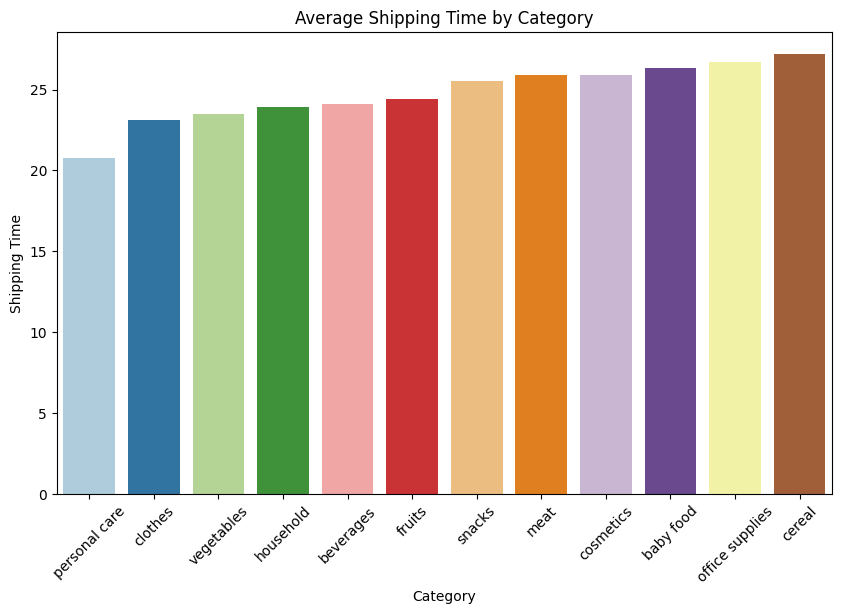

int64


In [ ]:
shipping_time_1 = df.groupby("Category")["Shipping Time"].mean().reset_index()
shipping_time_1 = shipping_time_1.sort_values("Shipping Time", ascending=True)

plt.figure(figsize=(10,6))
sns.barplot(data=shipping_time_1, x="Category", y="Shipping Time", palette="Paired")
plt.xticks(rotation=45)
plt.title("Average Shipping Time by Category")
plt.show()
print(df["Shipping Time"].dtype) # перевіряв чи в правильному форматі час доставки

Швидше всього доставляють засоби особичстої гігієни, одяг та овочі

/tmp/ipython-input-2608034610.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shipping_time_2, x="Country", y="Shipping Time", palette="Paired", )


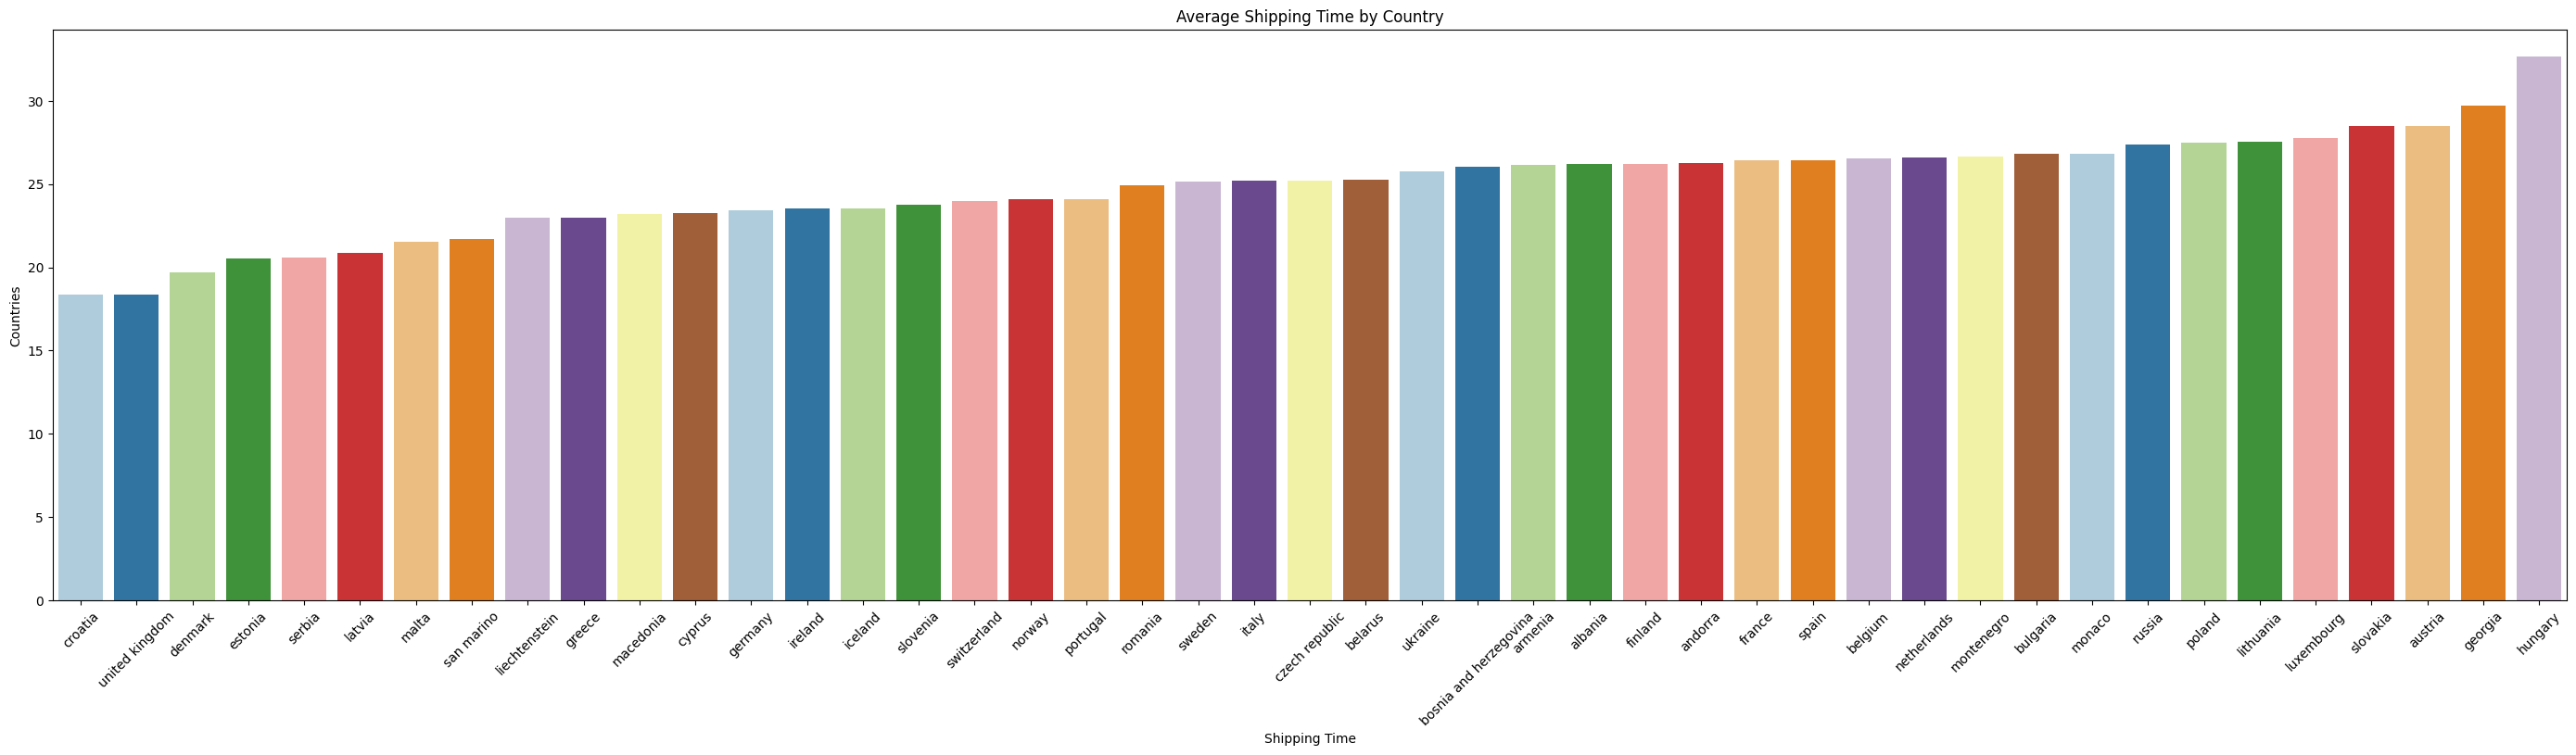

In [ ]:
shipping_time_2 = df.groupby("Country")["Shipping Time"].mean().reset_index()
shipping_time_2 = shipping_time_2.sort_values("Shipping Time", ascending=True)
plt.figure(figsize=(35,8))
sns.barplot(data=shipping_time_2, x="Country", y="Shipping Time", palette="Paired", )
plt.xticks(rotation=45)
plt.title("Average Shipping Time by Country")  # Title of the graph
plt.xlabel("Shipping Time")  # X-axis label
plt.ylabel("Countries")  # Y-axis label
plt.show()

Швидше усього доставляють в Хорватію, Велику Британію та Данію

/tmp/ipython-input-2089876055.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=shipping_time_3, x="Region", y="Shipping Time", palette="Paired")


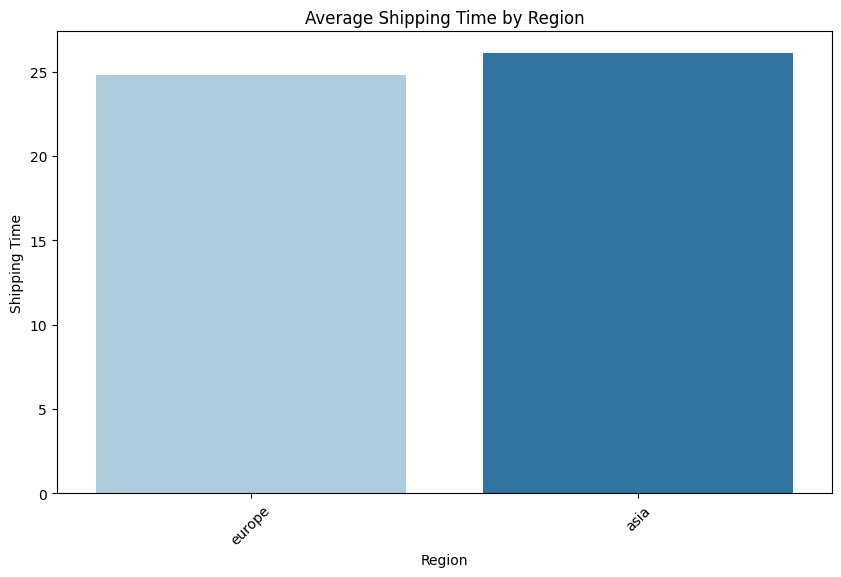

In [ ]:
shipping_time_3 = df.groupby("Region")["Shipping Time"].mean().reset_index()
shipping_time_3 = shipping_time_3.sort_values("Shipping Time", ascending=True)

plt.figure(figsize=(10,6))
sns.barplot(data=shipping_time_3, x="Region", y="Shipping Time", palette="Paired")
plt.xticks(rotation=45)
plt.title("Average Shipping Time by Region")
plt.show()


В Європу доставляють швидше

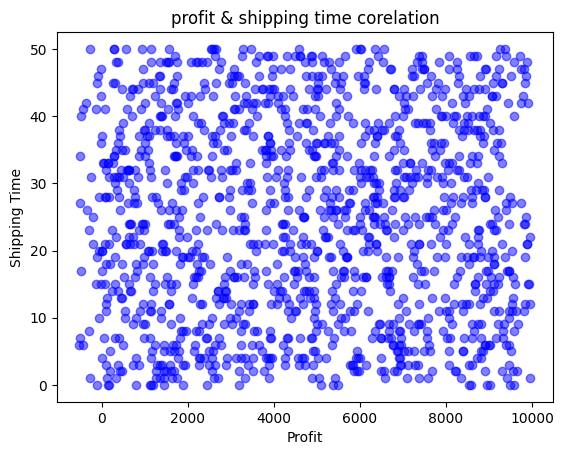

np.float64(0.009597703570479245)

In [ ]:
plt.scatter(df["Profit"], df["Shipping Time"], color="blue", alpha=0.5)
plt.title("profit & shipping time corelation")  # Title of the graph
plt.xlabel("Profit")  # X-axis label
plt.ylabel("Shipping Time")  # Y-axis label
plt.show()
df["Shipping Time"].corr(df["Profit"]) #вираховуємо кореляцію

Аналіз розсіювання та значення кореляції свідчать про відсутність лінійної залежності між часом доставки та прибутком. Це може означати, що прибутковість більше залежить від інших факторів (категорії товару, ціни, обсягу продажів тощо).

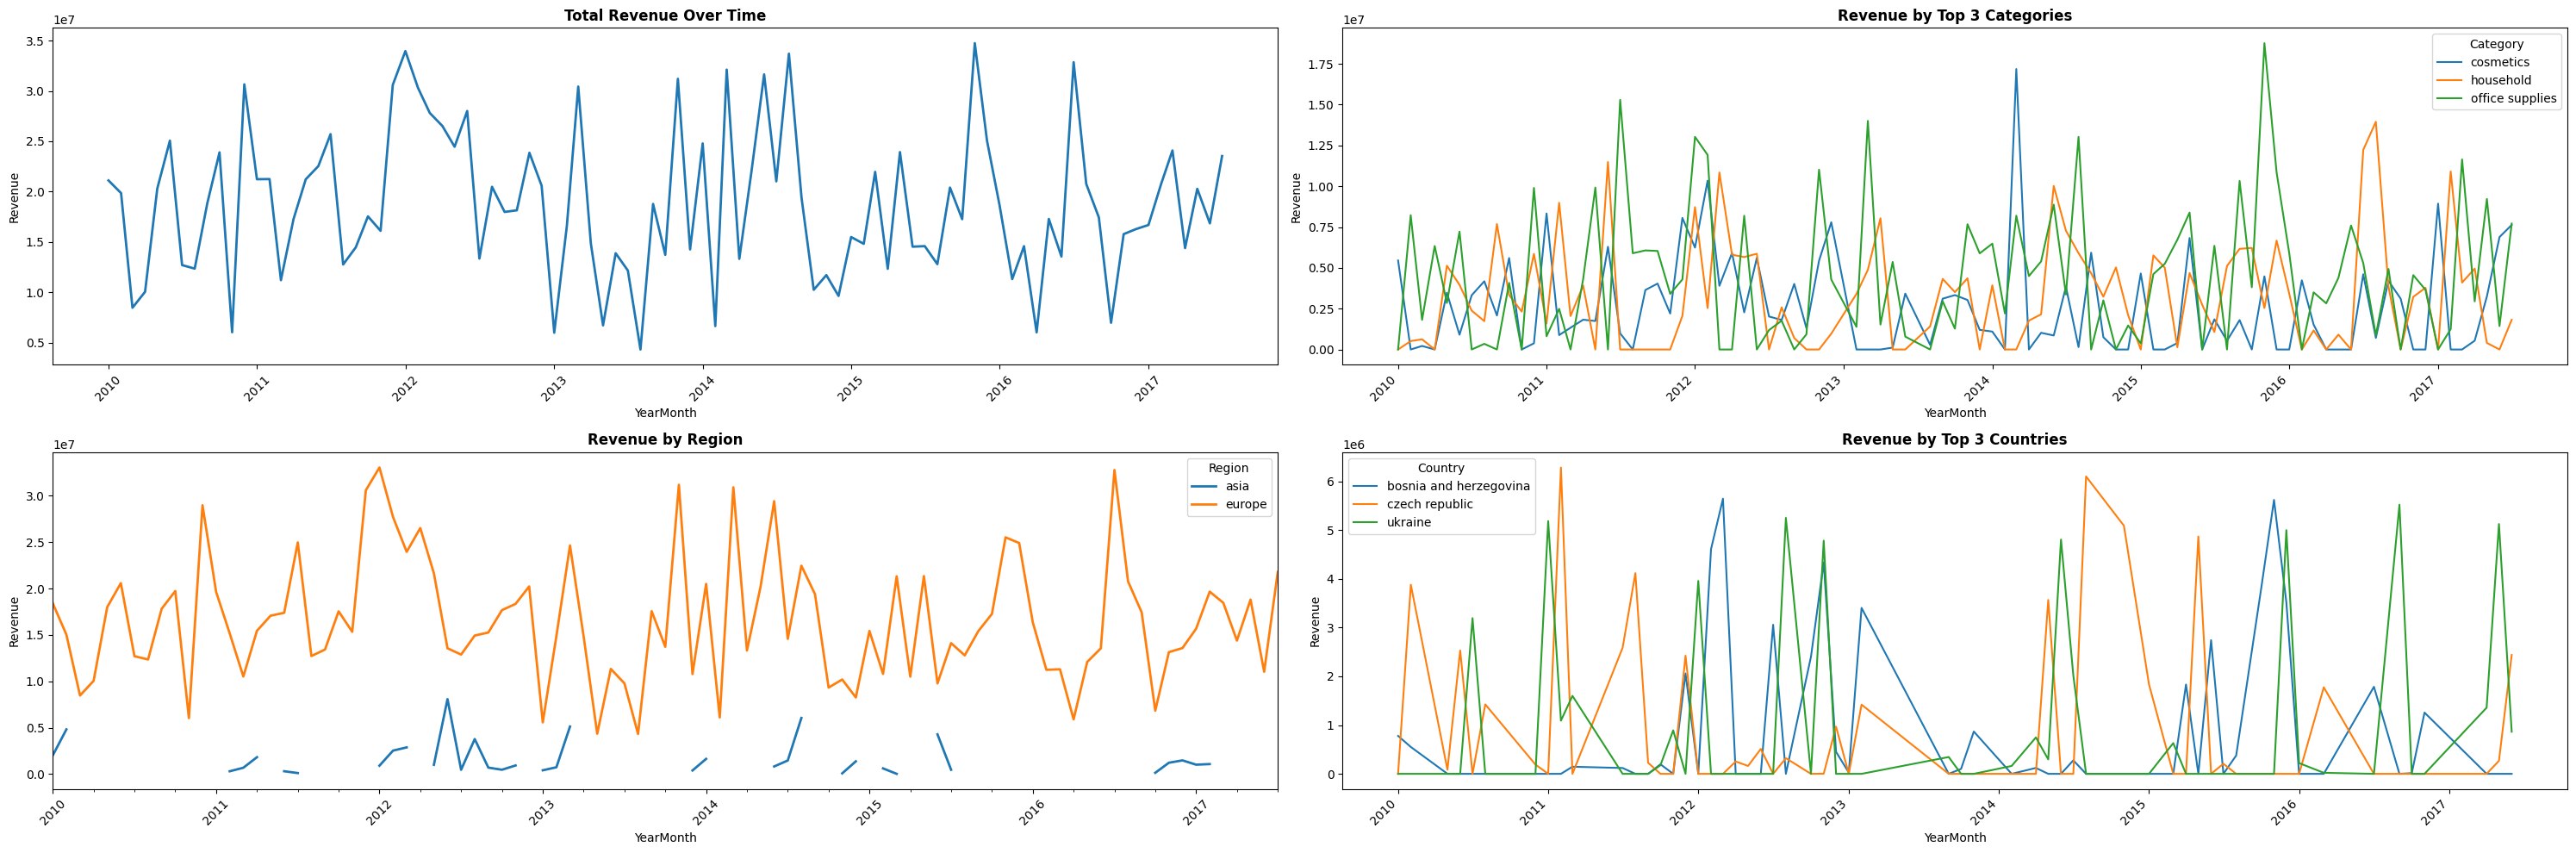

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(30,10))
total_trend = (df.groupby("YearMonth")["Revenue"].sum().sort_index)()#групуємо дохід по місяцям
ax[0,0].plot(total_trend.index, total_trend.values, linewidth=2)
ax[0,0].set_title("Total Revenue Over Time", fontweight="bold")
ax[0,0].set_xlabel("YearMonth")
ax[0,0].set_ylabel("Revenue")
ax[0,0].tick_params(axis='x', rotation=45)
top_categories = (df.groupby("Category")["Revenue"].sum().sort_values(ascending=False).head(3).index)#групуємо дохід по категоріям
category_trend = (df[df["Category"].isin(top_categories)].pivot_table(index="YearMonth", columns="Category",values="Revenue",aggfunc="sum").sort_index().fillna(0))#зведена таблиця топ 3 категорії по доходу
category_trend.plot(ax=ax[0,1])
ax[0,1].set_title("Revenue by Top 3 Categories", fontweight="bold")
ax[0,1].set_xlabel("YearMonth")
ax[0,1].set_ylabel("Revenue")
ax[0,1].tick_params(axis='x', rotation=45)
ax[0,1].legend(title="Category")
region_trend = (df.pivot_table(index="YearMonth",columns="Region",values="Revenue",aggfunc="sum").sort_index())
region_trend.plot(ax=ax[1,0], linewidth=2)
ax[1,0].set_title("Revenue by Region", fontweight="bold")
ax[1,0].set_xlabel("YearMonth")
ax[1,0].set_ylabel("Revenue")
ax[1,0].tick_params(axis='x', rotation=45)
ax[1,0].legend(title="Region")
top_countries = (df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(3).index)
country_trend = (
    df[df["Country"].isin(top_countries)].pivot_table(index="YearMonth",columns="Country",values="Revenue",aggfunc="sum").sort_index().fillna(0)
)
country_trend.plot(ax=ax[1,1])
ax[1,1].set_title("Revenue by Top 3 Countries", fontweight="bold")
ax[1,1].set_xlabel("YearMonth")
ax[1,1].set_ylabel("Revenue")
ax[1,1].tick_params(axis='x', rotation=45)
ax[1,1].legend(title="Country")


plt.tight_layout()
plt.show()

Загальна динаміка продажів характеризується високою волатильністю без чітко вираженого стабільного зростаючого тренду. Основний дохід формується в Європейському регіоні та в кількох ключових категоріях товарів. Продажі мають піковий характер, що може свідчити про значний вплив великих індивідуальних замовлень на загальні показники.

/tmp/ipython-input-2984862751.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_sales = (df.groupby("DayOfWeek")["Revenue"].sum().sort_index()) #групуємо дохід по дням тижня


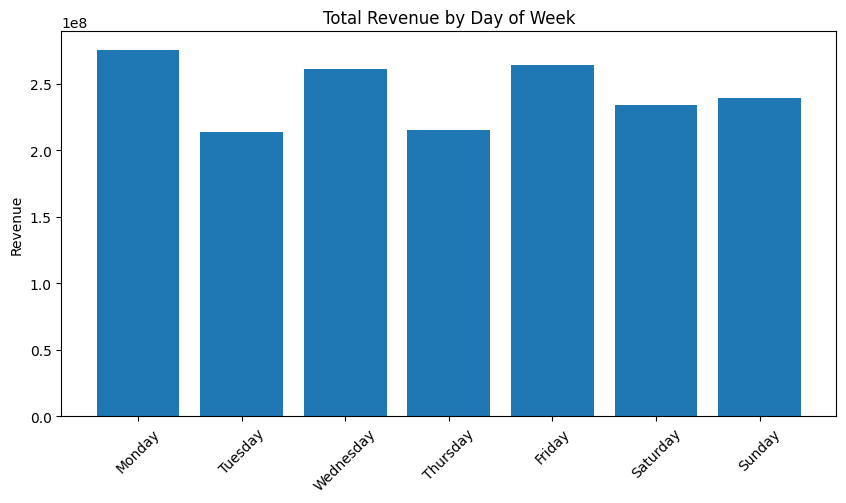

In [ ]:
weekday_sales = (df.groupby("DayOfWeek")["Revenue"].sum().sort_index()) #групуємо дохід по дням тижня
plt.figure(figsize=(10,5))
plt.bar(weekday_sales.index, weekday_sales.values)
plt.title("Total Revenue by Day of Week")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

Як ми бачимо по доходу лідирує понеділок, середа та п'ятниця

/tmp/ipython-input-3869074656.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  weekday_category = (df.pivot_table(index="DayOfWeek",columns="Category",values="Revenue",aggfunc="sum").sort_index())#створюємо півот, сорі звик так називати


<Figure size 3000x2000 with 0 Axes>

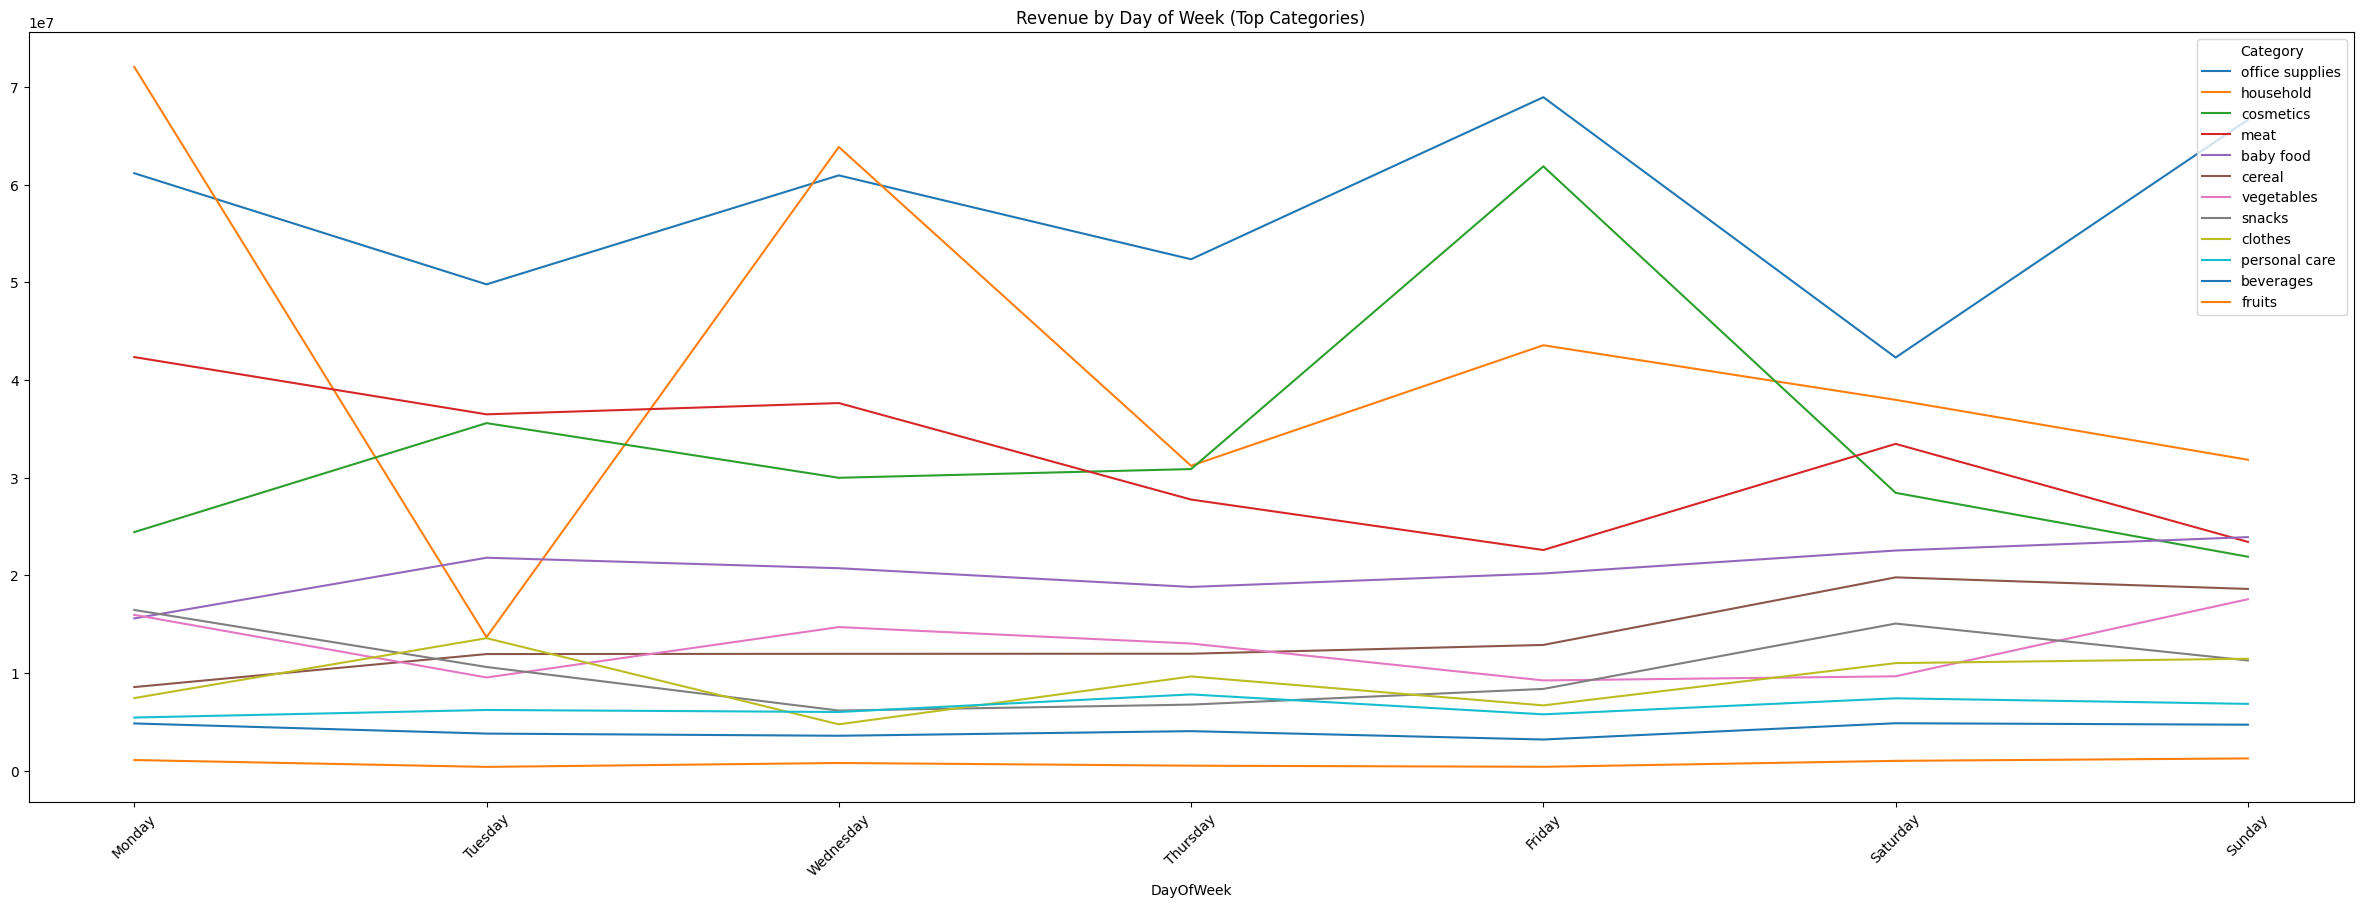

In [ ]:
weekday_category = (df.pivot_table(index="DayOfWeek",columns="Category",values="Revenue",aggfunc="sum").sort_index())#створюємо півот, сорі звик так називати
top_categories = (df.groupby("Category")["Revenue"].sum().sort_values(ascending=False).index)#групуємо та сортуємо за спаданням
weekday_category = weekday_category[top_categories]#фільтруємо півот
plt.figure(figsize=(30,20))
weekday_category.plot(figsize=(30,10))
plt.title("Revenue by Day of Week (Top Categories)")
plt.xticks(rotation=45)
plt.show()

Аналіз продажів за днями тижня показав відсутність вираженої сезонності товарів.
Водночас спостерігається помірний weekly-pattern: підвищений обсяг продажів у п’ятницю та понеділок і відносне зниження в суботу.
Це може свідчити про поведінкові особливості покупців (закупівлі перед вихідними та на початку робочого тижня).

# Фінальний висновок: За результатами аналізу встановлено, що бізнес демонструє загальну стабільність фінансових показників та зростання без ознак системної нестійкості. Основна частка доходу формується обмеженим колом ключових товарних категорій, що свідчить про концентрацію продажів у стратегічно важливих напрямах. Значний обсяг виручки генерується домінуючим регіоном, що вказує на географічну концентрацію бізнесу. Водночас суттєвої залежності прибутку від швидкості відвантаження не виявлено, а вираженої товарної сезонності у розрізі днів тижня не зафіксовано.